# This notebook tests making masks of the largest updraft objects from the time-height W stats data
## The steps include:
- Label the largest updraft objects within a specified CI time window
- Get updraft object top/base height & start/end times
- Make linear fit for updraft top height
- Compute distance between updraft base height & LCL
- Save output to netCDF file

In [1]:
import os
import glob
import time
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import xarray as xr
import scipy.stats as st
from matplotlib.colors import BoundaryNorm
# from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
# from matplotlib.figure import Figure
import matplotlib.gridspec as gridspec
import pandas as pd
import datetime
import copy
from scipy.stats import linregress
import seaborn as sns
import colorcet as cc
from sklearn.neighbors import KernelDensity
from scipy.ndimage import label, binary_dilation, generate_binary_structure, filters, iterate_structure
import warnings

In [2]:
# LASSO tracking directory
rootdir_les = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/'
rootdir_meso = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso/'
in_basename = 'trackstats_'
in_basename_w = 'stats_3d_w_'
in_basename_env = 'stats_1d_env_2location_'

figdir = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/'

case_date = '20181129.1200_20181130.0000'

tfiles = f'{rootdir_les}20181129/gefs00/base/d3/stats/{in_basename}{case_date}.nc'
wfiles = f'{rootdir_les}20181129/gefs00/base/d3/stats/{in_basename_w}{case_date}.nc'
envfiles = f'{rootdir_les}20181129/gefs00/base/d3/stats/{in_basename_env}{case_date}.nc'

out_basename = 'stats_2d_wmask_'
output_filename = f'{rootdir_les}20181129/gefs00/base/d3/stats/{out_basename}{case_date}.nc'

tfiles, wfiles, envfiles

('/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/20181129/gefs00/base/d3/stats/trackstats_20181129.1200_20181130.0000.nc',
 '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/20181129/gefs00/base/d3/stats/stats_3d_w_20181129.1200_20181130.0000.nc',
 '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/20181129/gefs00/base/d3/stats/stats_1d_env_2location_20181129.1200_20181130.0000.nc')

In [3]:
# Read track data
dst = xr.open_dataset(tfiles, engine='netcdf4')
ntracks = dst.sizes['tracks']
print(f'Number of tracks: {ntracks}')

# Read W data
dsw = xr.open_dataset(wfiles)

# Read ENV data (select CI location, drop 'height' dimension)
dse = xr.open_dataset(envfiles).sel(location=1).drop_dims(['height'])

# Combine datasets by coordinates
ds = xr.combine_by_coords([dst, dsw, dse], combine_attrs='drop_conflicts')
ntimes = ds.sizes['times']
ds

Number of tracks: 422


<xarray.Dataset> Size: 2GB
Dimensions:                  (tracks: 422, times: 212, z: 40, core: 10)
Coordinates:
  * tracks                   (tracks) int64 3kB 0 1 2 3 4 ... 418 419 420 421
  * times                    (times) int64 2kB -12 -11 -10 -9 ... 197 198 199
    location                 int64 8B 1
  * z                        (z) float64 320B 250.0 500.0 ... 2e+04 2.1e+04
  * core                     (core) int64 80B 0 1 2 3 4 5 6 7 8 9
Data variables: (12/184)
    conv_core                (tracks, times) float32 358kB 0.0 0.0 ... nan nan
    conv_mask                (tracks, times) float32 358kB 0.0 0.0 ... nan nan
    dbz_comp                 (tracks, times) float32 358kB -35.0 -35.0 ... nan
    echotop10                (tracks, times) float32 358kB nan nan ... nan nan
    LWP                      (tracks, times) float32 358kB 0.0 0.0 ... nan nan
    IWP                      (tracks, times) float32 358kB 0.0 0.0 ... nan nan
    ...                       ...
    start_split_tracknumber  (tracks) float64 3kB ...
    start_split_timeindex    (tracks) float64 3kB ...
    start_split_cloudnumber  (tracks) float64 3kB ...
    end_merge_tracknumber    (tracks) float64 3kB ...
    end_merge_timeindex      (tracks) float64 3kB ...
    end_merge_cloudnumber    (tracks) float64 3kB ...
Attributes:
    title:                 Tracked cell W statistics
    source_trackfile:      /gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/2018...
    startdate:             20181129.1200
    enddate:               20181130.0000
    timegap_hour:          0.5
    time_resolution_hour:  0.08333
    pixel_radius_km:       0.5

In [4]:
# Get some constents common for all Datasets
ntimes = ds.sizes['times']
nz = ds.sizes['z']
ncores = ds.sizes['core']

time_res = 5.0  # [min]
time_coord = ds.times
xtime = ds.times * time_res
height = ds.z / 1000.

## Filter updraft variables above max ETH

In [5]:
# Buffer height above which to filter updraft variables [km]
ETH_buffer = 1.0

In [6]:
# Filter largest updrafts above 10dBZ ETH + buffer
maxETH_10dbz = ds['maxETH_10dbz'].load()
CoreArea_up = ds['CoreArea_up'].where(height <= maxETH_10dbz+ETH_buffer).isel(core=0).load()
CoreMaxW_up = ds['CoreMaxW_up'].where(height <= maxETH_10dbz+ETH_buffer).isel(core=0).load()

# # Number of sample at each time & height for all tracks
# nsample_CoreArea_up_narrow_shallow_d2 = (CoreArea_up_narrow_shallow_d2 > 0).sum(dim='tracks')
# nsample_CoreArea_up_narrow_deep_d2 = (CoreArea_up_narrow_deep_d2 > 0).sum(dim='tracks')
# # Make 0 sample NaN
# nsample_CoreArea_up_narrow_deep_d2 = nsample_CoreArea_up_narrow_deep_d2.where(nsample_CoreArea_up_narrow_deep_d2 > 0)
# nsample_CoreArea_up_narrow_shallow_d2 = nsample_CoreArea_up_narrow_shallow_d2.where(nsample_CoreArea_up_narrow_shallow_d2 > 0)

In [7]:
CoreArea_up.shape

(422, 212, 40)

## Get preCI environmental variables: LCL, LFC

In [8]:
# Time for representative environment
time_env = -3

# Convert AGL to HAMSL, then select a representative time before CI
LCL_mu = (ds['LCL_height_mu'] + ds['Z_surface']).sel(times=time_env) / 1000.
LFC_mu = (ds['LFC_height_mu'] + ds['Z_surface']).sel(times=time_env) / 1000.

(array([ 47., 121., 165.,  60.,  19.,   8.,   0.,   1.,   0.,   1.]),
 array([2.0142064, 2.3836412, 2.753076 , 3.1225107, 3.4919455, 3.8613803,
        4.230815 , 4.60025  , 4.9696846, 5.3391194, 5.7085543],
       dtype=float32),
 <BarContainer object of 10 artists>)

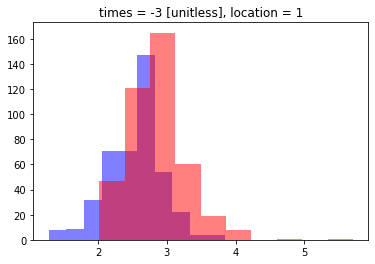

In [9]:
LCL_mu.plot.hist(color='b', alpha=0.5)
LFC_mu.plot.hist(color='r', alpha=0.5)

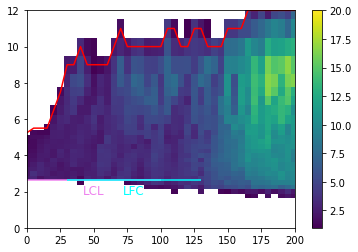

In [10]:
itrack = 2
plt.pcolormesh(xtime, height, 2*np.sqrt(CoreArea_up.isel(tracks=itrack).transpose()/np.pi), shading='nearest')
plt.plot(xtime, maxETH_10dbz.isel(tracks=itrack), color='r')
line_length = 100
LCL_t0 = 0
LCL_t1 = LCL_t0 + line_length
LFC_t0 = 30
LFC_t1 = LFC_t0 + line_length
plt.hlines(y=LCL_mu.isel(tracks=itrack), xmin=LCL_t0, xmax=LCL_t1, color='violet')
plt.hlines(y=LFC_mu.isel(tracks=itrack), xmin=LFC_t0, xmax=LFC_t1, color='cyan')
LCL_text_x = LCL_t0 + line_length / 2
LCL_text_y = LCL_mu.isel(tracks=itrack)-0.2
LFC_text_x = LFC_t0 + line_length / 2
LFC_text_y = LFC_mu.isel(tracks=itrack)-0.2
plt.text(LCL_text_x, LCL_text_y, 'LCL', ha='center', va='top', color='violet', fontsize=12)
plt.text(LFC_text_x, LFC_text_y, 'LFC', ha='center', va='top', color='cyan', fontsize=12)
plt.xlim(0,200)
plt.ylim(0,12)
plt.colorbar()

In [11]:
# Get updraft track coordinates
c_times = CoreMaxW_up.coords['times'].data
c_z = CoreMaxW_up.coords['z'].data

# Define a time window to sample updraft
time_start = 0  # [min]
time_end = 60  # [min]
tidx_start = np.where(xtime == time_start)[0].item()
tidx_end = np.where(xtime == time_end)[0].item()
print(tidx_start, tidx_end)

12 24


In [12]:
zmax = height[5].values+0.5
zmax

2.0

In [13]:
height.values

array([ 0.25,  0.5 ,  0.75,  1.  ,  1.25,  1.5 ,  1.75,  2.  ,  2.25,
        2.5 ,  2.75,  3.  ,  3.25,  3.5 ,  3.75,  4.  ,  4.25,  4.5 ,
        4.75,  5.  ,  5.25,  5.5 ,  6.  ,  6.5 ,  7.  ,  7.5 ,  8.  ,
        9.  , 10.  , 11.  , 12.  , 13.  , 14.  , 15.  , 16.  , 17.  ,
       18.  , 19.  , 20.  , 21.  ])

In [14]:
# np.argmin(np.abs(height.values - zmax))
np.argmin(np.abs(height.values - zmax))

7

In [15]:
# cbase_depth = 0.5
# cbase = np.array([2,2,2.5,2,1.5])
# cbase_max = cbase + cbase_depth
# cbase_max

height.values[5:5]

array([], dtype=float64)

## Make 2D updraft object masks for each track 

In [16]:
def get_W_properties(W_array, tidx_start, tidx_end, cbase_depth):
    """
    Get W object properties given a W 2D array
    
    Args:
        W_array: np.array [times, height]
            W 2D array.
        tidx_start: int
            Start time index to subset W object.
        tidx_end: int
            End time index to subset W object.
        cbase_depth: float
            Depth above cloud base to compute W statistics [km].
            
    Returns:
        out_dict: dictionary
            A dictionary containing W object property variables.    
    """
    
    # Make a binary array for W
    W_binary = np.zeros_like(W_array)
    W_binary[W_array > 0] = 1
    
    # Label the connected pixels
    label_image, n_obj = label(W_binary > 0)
    # Trim the times, then get the unique values of the labeled image, and the pixel counts
    label_num_, npix_ = np.unique(label_image[tidx_start:tidx_end,:], return_counts=True)
    # Trim the 0 (not an object), then count the number of W objects
    label_num_W = np.trim_zeros(label_num_)
    n_obj_W = len(label_num_W)

    # Make output arrays
    mask_time2d = np.zeros(label_image.shape)
    mask_large = np.full(label_image.shape, np.NaN)
    mask_remove = np.full(label_image.shape, np.NaN)
    max_indices_z = np.full(label_image.shape, -1, dtype=int)
    mask_top = np.full(label_image.shape[0], np.NaN)
    mask_base = np.full(label_image.shape[0], np.NaN)
    Wtime_start = np.NaN
    Wtime_end = np.NaN
    Wlifetime = np.NaN
    Wbase_mean = np.NaN
    Wbase_median = np.NaN

    # Get the size (pixel count) of the W objects
    if n_obj_W > 0:
        # Exclude the first value (0)
        npix_W = npix_[1:]
        # Get the largest object number
        big_cell = label_num_W[np.argmax(npix_W)]

        # Mask time window to keep object    
        mask_time2d[tidx_start:tidx_end+1,:] = 1
        # Make a binary mask of the largest object
        mask_large[(label_image==big_cell) & (mask_time2d==1)] = 1
        # Make a mask for removing object (for plotting purpose)
        mask_remove[(mask_large != 1) & (W_binary > 0)] = 1

        #------------------------------------
        # Get updraft top heights
        # Get indices of the last occurrence of the max value along the y-axis (height)
        max_indices_z = np.argmax(mask_large[:,::-1]==1, axis=1)
        # Invert the indices to get the correct position along the original y-axis
        max_indices_z = mask_large.shape[1] - 1 - max_indices_z
        # Filter out indices where the mask is False
        max_indices_z[np.isnan(np.nanmax(mask_large, axis=1))] = -1
        # Apply indices to height array using advanced indexing
        mask_top = height.data[max_indices_z]
        # Replace times when indices is invalid with NaN (< 0)
        mask_top[max_indices_z < 0] = np.NaN
        #------------------------------------
        #------------------------------------
        # Get updraft base heights
        # Get indices of the last occurrence of the max value along the y-axis (height)
        min_indices_z = np.argmax(mask_large==1, axis=1)
        # Filter out indices where the mask is False
        min_indices_z[np.isnan(np.nanmax(mask_large, axis=1))] = -1
        # Apply indices to height array using advanced indexing
        mask_base = height.data[min_indices_z]
        # Replace times when indices is invalid with NaN (< 0)
        mask_base[min_indices_z < 0] = np.NaN
        
        # Take median value for updraft base heights
        median_base = np.nanmedian(mask_base)
        # Get base height + depth
        median_base_top = median_base + cbase_depth
        # Get z indices
        median_base_z0 = np.argmin(np.abs(height.values - median_base))
        median_base_z1 = np.argmin(np.abs(height.values - median_base_top))
        # print(median_base, median_base_top)
        # print(median_base_z0, median_base_z1)
        # Mask out small cores
        W_array[mask_remove == 1] = np.NaN
        # Check if layer top > base
        if (median_base_z1 > median_base_z0):
            Wbase_mean = np.nanmean(W_array[:,median_base_z0:median_base_z1+1])
            Wbase_median = np.nanmedian(W_array[:,median_base_z0:median_base_z1+1])
        else:
            Wbase_mean = np.nanmean(W_array[:,median_base_z0])
            Wbase_median = np.nanmedian(W_array[:,median_base_z0])
        #------------------------------------

        # Find start/end time indices of the largest object
        # tind, zind = np.where(label_image==big_cell)
        tind, zind = np.where(mask_large == 1)
        istart, iend = min(tind), max(tind)
        # Mark start/end time and lifetime
        Wtime_start = time_coord.values[istart].item()
        Wtime_end = time_coord.values[iend].item()
        Wlifetime = (iend - istart + 1) * time_res

    # Put outputs to a dictionary
    out_dict = {
        'mask_large': mask_large,
        'mask_remove': mask_remove,
        'mask_top': mask_top,
        'mask_base': mask_base,
        'Wtime_start': Wtime_start,
        'Wtime_end': Wtime_end,
        'Wlifetime': Wlifetime,
        'Wbase_mean': Wbase_mean,
        'Wbase_median': Wbase_median,
    }
        
    return out_dict

In [17]:
def make_W_mask(da_W, maxETH_10dbz, tidx_start, tidx_end, cbase_depth=0.5):
    """
    Make W object masks for all tracks
    
    Args:
        da_W: DataArray [tracks, times, height]
            Data array containing W.
        maxETH_10dbz: DataArray [tracks, times]
            Max 10dBZ echo-top height.
        tidx_start: int
            Start time index to subset W object.
        tidx_end: int
            End time index to subset W object.
        cbase_depth: float
            Depth above cloud base to compute W statistics [km].
            
    Returns:
        out_dict: dictionary
            A dictionary containing W object property variables.    
    """

    # Make a binary array for W
    # binary_w = np.zeros_like(da_W)
    # binary_w[da_W > 0] = 1
    
    # Make output arrays
    _ntracks = da_W.sizes['tracks']
    _ntimes = da_W.sizes['times']
    Wmask = np.full(da_W.shape, np.NaN)
    Wmask_remove = np.full(da_W.shape, np.NaN)
    Wtime_start = np.full(_ntracks, np.NaN)
    Wtime_end = np.full(_ntracks, np.NaN)
    Wlifetime = np.full(_ntracks, np.NaN)
    Wtop = np.full((_ntracks, _ntimes), np.NaN)
    Wbase = np.full((_ntracks, _ntimes), np.NaN)
    Wbase_mean = np.full(_ntracks, np.NaN)
    Wbase_median = np.full(_ntracks, np.NaN)
    # maxETH_filter = np.copy(maxETH_10dbz.values)
    maxETH_filter = np.full(maxETH_10dbz.shape, np.NaN)

    # Loop over each track
    for itrack in range(0, _ntracks):
        # # Get the binary mask for this track
        # iW_binary = binary_w[itrack,:,:].squeeze()
        # # Call function to get W object properties
        # iW_object_dict = get_W_properties(iW_binary, tidx_start, tidx_end)
        
        # Get W for this track
        iW = (da_W.isel(tracks=itrack).squeeze().values).copy()
        iETH = (maxETH_10dbz.isel(tracks=itrack).squeeze().values).copy()
        # Call function to get W object properties
        iW_object_dict = get_W_properties(iW, tidx_start, tidx_end, cbase_depth)
        
        # Save values to output arrays
        Wmask[itrack,:,:] = iW_object_dict['mask_large']
        Wmask_remove[itrack,:,:] = iW_object_dict['mask_remove']
        Wtop[itrack,:] = iW_object_dict['mask_top']
        Wbase[itrack,:] = iW_object_dict['mask_base']
        Wtime_start[itrack] = iW_object_dict['Wtime_start']
        Wtime_end[itrack] = iW_object_dict['Wtime_end']
        Wlifetime[itrack] = iW_object_dict['Wlifetime']
        Wbase_mean[itrack] = iW_object_dict['Wbase_mean']
        Wbase_median[itrack] = iW_object_dict['Wbase_median']
        # Filter ETH after Wtime_end
        if Wtime_end[itrack] > 0:
            _Wtime_end = int(Wtime_end[itrack])
            # Find matching index from the time_coord
            _tidx = np.where(time_coord == _Wtime_end)[0].item()
            iETH[_tidx+1:] = np.NaN
            maxETH_filter[itrack,:] = iETH
            # maxETH_filter[itrack,Wend_tidx+1:] = np.NaN

    # Convert to DataArrays
    Wmask = xr.DataArray(Wmask, coords=da_W.coords, dims=('tracks','times','z'))
    Wmask_remove = xr.DataArray(Wmask_remove, coords=da_W.coords, dims=('tracks','times','z'))
    Wtop = xr.DataArray(Wtop, coords={'tracks':da_W.coords['tracks'], 'times':da_W.coords['times']}, dims=('tracks','times'))
    Wbase = xr.DataArray(Wbase, coords={'tracks':da_W.coords['tracks'], 'times':da_W.coords['times']}, dims=('tracks','times'))
    Wtime_start = xr.DataArray(Wtime_start, coords={'tracks':da_W.coords['tracks']}, dims=('tracks'))
    Wtime_end = xr.DataArray(Wtime_end, coords={'tracks':da_W.coords['tracks']}, dims=('tracks'))
    Wlifetime = xr.DataArray(Wlifetime, coords={'tracks':da_W.coords['tracks']}, dims=('tracks'))
    Wbase_mean = xr.DataArray(Wbase_mean, coords={'tracks':da_W.coords['tracks']}, dims=('tracks'))
    Wbase_median = xr.DataArray(Wbase_median, coords={'tracks':da_W.coords['tracks']}, dims=('tracks'))
    maxETH_filter = xr.DataArray(maxETH_filter, coords={'tracks':maxETH_10dbz.coords['tracks'], 'times':maxETH_10dbz.coords['times']}, dims=('tracks','times'))
    # Put outputs in a dictionary
    out_dict = {
        'Wmask': Wmask,
        'Wmask_remove': Wmask_remove,
        'Wtop': Wtop,
        'Wbase': Wbase,
        'Wtime_start': Wtime_start,
        'Wtime_end': Wtime_end,
        'Wlifetime': Wlifetime,
        'Wbase_mean': Wbase_mean,
        'Wbase_median': Wbase_median,
        'maxETH_10dbz_filter': maxETH_filter,
    }
    return out_dict


In [18]:
CoreArea_up.shape, maxETH_10dbz.shape, time_coord.shape

((422, 212, 40), (422, 212), (212,))

In [19]:
# # maxETH_10dbz.coords
# cbase_depth = 0.5

# itrack = 2
# # # Get W for this track
# iW = (CoreArea_up.isel(tracks=itrack).squeeze().values).copy()
# iETH = (maxETH_10dbz.isel(tracks=itrack).squeeze().values).copy()
# # # iW.shape

# # # iW.values

# # # Call function to get W object properties
# iW_object_dict = get_W_properties(iW, tidx_start, tidx_end, cbase_depth)
# # iW_object_dict['Wbase_mean']
# _Wtime_end = iW_object_dict['Wtime_end']
# # _Wtime_end = int(Wtime_end[itrack].item())
# _tidx = np.where(time_coord == _Wtime_end)[0].item()
# # _tidx
# # Wend_tidx = int(_Wtime_end)
# iETH[_tidx+1:] = np.NaN
# iETH

In [20]:
# Make W object masks
cbase_depth = 0.5

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    Wmask_dict = make_W_mask(CoreArea_up, maxETH_10dbz, tidx_start, tidx_end, cbase_depth)
Wmask_dict.keys()

dict_keys(['Wmask', 'Wmask_remove', 'Wtop', 'Wbase', 'Wtime_start', 'Wtime_end', 'Wlifetime', 'Wbase_mean', 'Wbase_median', 'maxETH_10dbz_filter'])

In [21]:
Wmask_dict['Wmask'].shape, Wmask_dict['Wbase_mean'].shape, CoreArea_up.shape

((422, 212, 40), (422,), (422, 212, 40))

(array([251., 114.,  24.,  10.,   6.,   3.,   2.,   2.,   1.,   1.]),
 array([ 0.75      ,  3.6833334 ,  6.61666679,  9.55000019, 12.48333359,
        15.41666698, 18.35000038, 21.28333378, 24.21666718, 27.15000057,
        30.08333397]),
 <BarContainer object of 10 artists>)

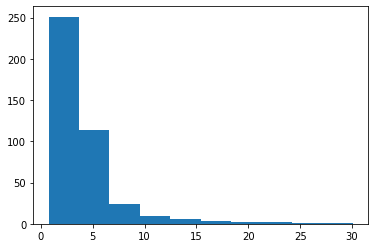

In [22]:
Wmask_dict['Wbase_mean'].plot.hist()

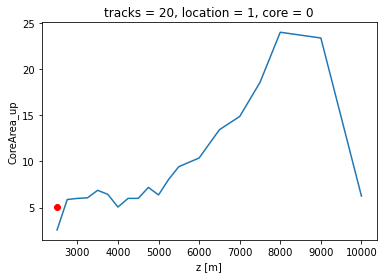

In [23]:
itrack = 20
CoreArea_up.where(Wmask_dict['Wmask']==1).sel(tracks=itrack).mean(dim='times').plot()
zz = Wmask_dict['Wbase'].sel(tracks=itrack).median()
ww = Wmask_dict['Wbase_mean'].sel(tracks=itrack)
plt.scatter(zz*1000, ww, color='r')
# Wmask_dict['Wbase_mean'].sel(tracks=itrack).plot(marker='o', color='red')

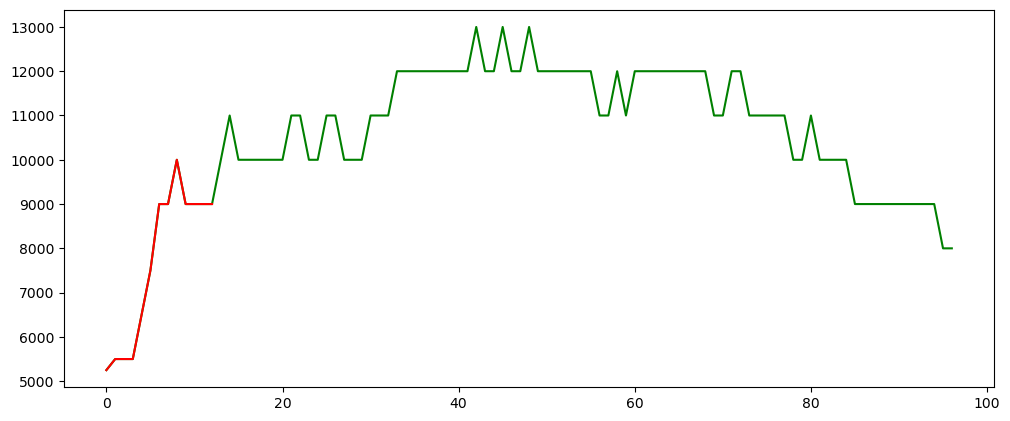

In [24]:
# Wmask_dict['Wmask_remove'].sel(tracks=2).plot()

# np.count_nonzero(~np.isnan(Wmask_dict['Wmask_remove']))
# Wmask_dict['maxETH_10dbz'].plot()

fig, ax = plt.subplots(1,1, dpi=100, figsize=(12,5))
itrack = 2
ax.plot(time_coord, maxETH_10dbz.sel(tracks=itrack)*1000, color='g', ls='-')
ax.plot(time_coord, Wmask_dict['maxETH_10dbz_filter'].sel(tracks=itrack)*1000, color='r')

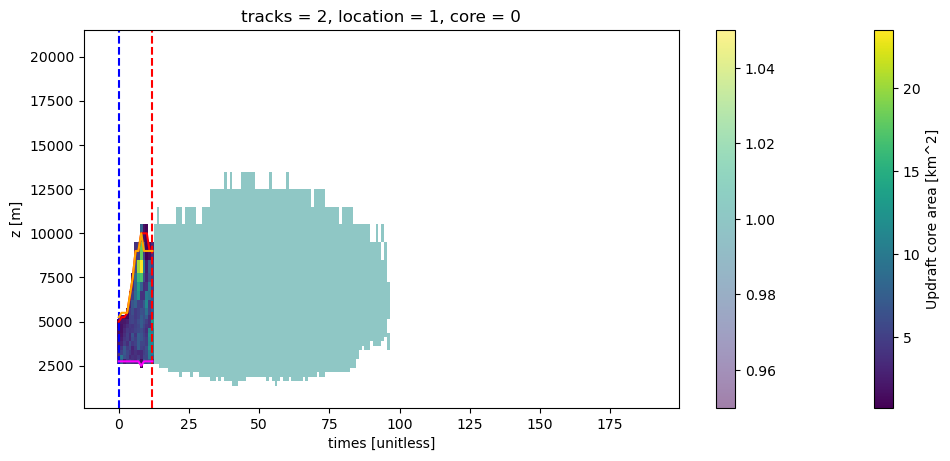

In [25]:
fig, ax = plt.subplots(1,1, dpi=100, figsize=(12,5))
itrack = 2

# Wmask_dict['Wmask'].sel(tracks=itrack).transpose().plot(ax=ax)
# CoreArea_up.sel(tracks=itrack).transpose().plot(ax=ax)
CoreArea_up.where(Wmask_dict['Wmask']==1).sel(tracks=itrack).transpose().plot(ax=ax)
Wmask_dict['Wmask_remove'].sel(tracks=itrack).transpose().plot(alpha=0.5, ax=ax)
ax.axvline(Wmask_dict['Wtime_start'].sel(tracks=itrack), color='b', ls='--')
ax.axvline(Wmask_dict['Wtime_end'].sel(tracks=itrack), color='r', ls='--')
ax.plot(time_coord, Wmask_dict['Wtop'].sel(tracks=itrack)*1000, color='r')
ax.plot(time_coord, Wmask_dict['maxETH_10dbz_filter'].sel(tracks=itrack)*1000, color='orange')
# ax.plot(time_coord, maxETH_10dbz.sel(tracks=itrack)*1000, color='gold')
ax.plot(time_coord, Wmask_dict['Wbase'].sel(tracks=itrack)*1000, color='magenta')

## Function to fit a linear line for cloud-top height within a time period

In [26]:
def fit_linear(xtime, Wtop, tidx_end, min_nsample=3):
    """
    Perform linear fit to a 1D time series array
    
    Args:
        xtime: np.array
            Array containing time values
        Wtop: np.array
            Array containing values to be fitted
        tidx_end: int
            Max time index to subset the time series before fitting
        min_nsample: int
            Minimum number of valid samples for fitting
            
    Returns:
        out_dict: dictionary
            A dictionary containing W object property variables.    
    """
    # Set default values
    slope, intercept, r_value, p_value, std_err = np.NaN, np.NaN, np.NaN, np.NaN, np.NaN
    nt = len(xtime)
    predicted_x = np.full(nt, np.NaN, dtype=np.float32)
    predicted_y = np.full(nt, np.NaN, dtype=np.float32)
    
    # Subset Wtop time period
    Wtop_sub = Wtop[0:tidx_end+1]
    # Make sure there are valid samples
    if np.count_nonzero(~np.isnan(Wtop_sub)) > 0:
        # Find time index for max Wtop within the subet time period
        _Wtop_max_tidx = Wtop_sub.argmax().item()

        # Subset times to Wtop max
        _xtime = xtime.data[0:_Wtop_max_tidx+1]
        _Wtop = Wtop.data[0:_Wtop_max_tidx+1]

        # Find valid value time indices
        tidx_valid = _Wtop > 0
        n_valid = np.count_nonzero(tidx_valid)
        # print(n_valid)
        if (n_valid >= min_nsample):
            _xtime = _xtime[tidx_valid]
            _Wtop = _Wtop[tidx_valid]

            # Perform linear regression
            slope, intercept, r_value, p_value, std_err = linregress(_xtime, _Wtop)

            # Find indices matching the subsetted time to the full time
            t_idx = np.where(np.isin(xtime, _xtime))[0]
            # Save the valid subsetted time
            predicted_x[t_idx] = _xtime
            # Predict y values using the linear fit
            predicted_y[t_idx] = slope * _xtime + intercept
        
    # Put output values in a dictionary
    out_dict = {
        'slope': slope,
        'intercept': intercept,
        'r_value': r_value,
        'p_value': p_value,
        'std_err': std_err,
        'predicted_x': predicted_x,
        'predicted_y': predicted_y,
    }
    return out_dict

## Calculate linear fit for updraft-top height

In [27]:
# Minimum number of sample to fit updraft top height
# min_nsample_fit = 3
min_nsample_fit = 2

In [28]:
# Wtop_s = Wmask_dict['Wtop'].isel(tracks=161)[0:tidx_end+1]
# np.count_nonzero(~np.isnan(Wtop_s))

In [29]:
# Make arrays to store data (narrow cells)
ntracks = Wmask_dict['Wtop'].sizes['tracks']
Wtop_slope = np.full(ntracks, np.NaN, dtype=np.float32)
Wtop_fit = np.full((ntracks, ntimes), np.NaN, dtype=np.float32)

# Loop over each track (narrow cells)
for itrack in range(ntracks):
    # print(itrack)
    _Wtop = Wmask_dict['Wtop'].isel(tracks=itrack)
    fit_dict = fit_linear(xtime, _Wtop, tidx_end, min_nsample=min_nsample_fit)
    Wtop_slope[itrack] = fit_dict['slope']
    Wtop_fit[itrack,:] = fit_dict['predicted_y']

(array([55., 57., 32., 38., 16.,  3.,  6.,  0.,  1.,  1.]),
 array([0.005     , 0.0645    , 0.12400001, 0.1835    , 0.24300002,
        0.3025    , 0.36200002, 0.42150003, 0.481     , 0.54050004,
        0.6       ], dtype=float32),
 <BarContainer object of 10 artists>)

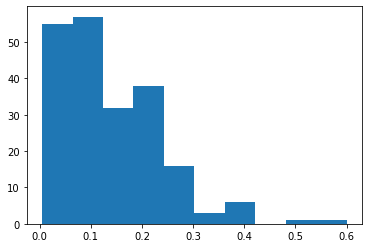

In [30]:
plt.hist(Wtop_slope)

## Make a flag for tracks with positive updraft top slope, and updraft base close to LCL

In [31]:
# Threshold for max distance between updraft base and LCL height [km]
max_Wbase_LCL_dist = 2.0
# Threshold for updraft top fit line slope
min_Wtop_slope = 0

In [32]:
# Calculate distance between minimum updraft base height and MU LCL height (HAMSL)
Wbase_LCL_diff = np.absolute(Wmask_dict['Wbase'].min(dim='times') - LCL_mu)

# True/False flag for positive slope
Wtop_Pslope = Wtop_slope > min_Wtop_slope
# True/False flag for updraft base height from LCL
Wbase_LCL = Wbase_LCL_diff <= max_Wbase_LCL_dist

# Convert boolean arrays to integer arrays (True -> 1, False -> 0)
Wtop_Pslope_int = Wtop_Pslope.astype(np.int8)
Wbase_LCL_int = Wbase_LCL.astype(np.int8)

# # Both positive slope & updraft base flag
# Wkeep_flag = (Wtop_Pslope & Wbase_LCL).compute()
# # Track indicies to keep
# Wid_keep = np.where(Wkeep_flag)[0]

(array([239.,  70.,  26.,  24.,  27.,  11.,   3.,   6.,   5.,   3.]),
 array([6.47068024e-04, 3.32937884e-01, 6.65228701e-01, 9.97519517e-01,
        1.32981033e+00, 1.66210115e+00, 1.99439197e+00, 2.32668278e+00,
        2.65897360e+00, 2.99126441e+00, 3.32355523e+00]),
 <BarContainer object of 10 artists>)

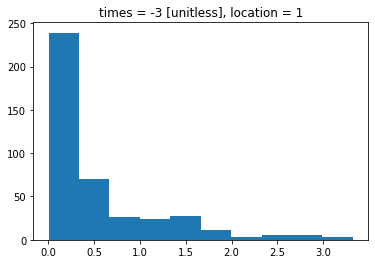

In [33]:
Wbase_LCL_diff.plot.hist()

In [34]:
Wmask_dict.keys()

dict_keys(['Wmask', 'Wmask_remove', 'Wtop', 'Wbase', 'Wtime_start', 'Wtime_end', 'Wlifetime', 'Wbase_mean', 'Wbase_median', 'maxETH_10dbz_filter'])

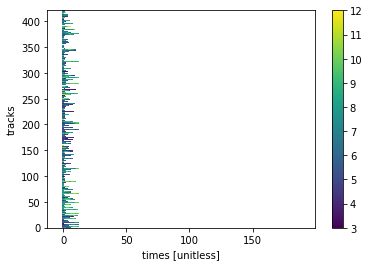

In [35]:
Wmask_dict['Wtop'].plot()

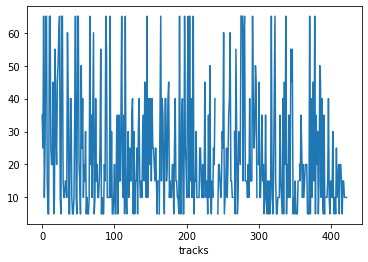

In [36]:
Wmask_dict['Wlifetime'].plot()

In [37]:
Wmask_dict['Wtime_end']

<xarray.DataArray (tracks: 422)> Size: 3kB
array([ 6.,  4., 12.,  1.,  4., 12., 12.,  2.,  0.,  0., 12., 12.,  4.,
        3.,  3.,  8.,  0.,  1., 10.,  5.,  3.,  8.,  9., 11., 12.,  1.,
        0., 12., 12.,  2.,  1.,  1.,  2.,  2.,  1., 11.,  7.,  0.,  0.,
        7.,  7.,  1.,  0.,  0.,  1.,  6., 12.,  1.,  0., 12., 12.,  3.,
        2.,  0.,  9.,  4.,  7.,  1.,  3.,  2.,  5.,  0.,  1.,  0.,  0.,
        1., 12.,  3.,  6.,  1.,  6., 11.,  0.,  1.,  7.,  2.,  3.,  1.,
        1.,  2.,  4., 10.,  0.,  1.,  0.,  0.,  3.,  2., 12., 10.,  1.,
        1.,  1.,  1., 12.,  1.,  5.,  0.,  0.,  1.,  3.,  0.,  0.,  5.,
        6.,  0.,  6.,  2.,  2.,  6., 12.,  2.,  1.,  6.,  0., 12.,  1.,
        0.,  2.,  5.,  1.,  4.,  2.,  2.,  6.,  7.,  0.,  5.,  0.,  2.,
        2.,  4.,  0.,  5.,  7.,  2.,  1.,  2.,  1.,  5.,  6.,  2.,  8.,
        7.,  1., 12.,  1.,  7.,  7.,  3.,  7.,  2.,  7.,  4.,  4.,  3.,
        2.,  4.,  2.,  0.,  2., nan,  0.,  6., 12.,  2.,  7.,  6.,  2.,
        0.,  7.,  7.,  2.,  3.,  7.,  8.,  1.,  2.,  1.,  1.,  3.,  3.,
        0.,  4.,  7.,  2.,  2.,  1.,  1.,  0., 12.,  1.,  0.,  6.,  7.,
        0.,  0., 12.,  4.,  3.,  1.,  8., 12.,  1., 12.,  2.,  7.,  1.,
        1., 12.,  0.,  2.,  2.,  5.,  1.,  1.,  1.,  1.,  4.,  4.,  2.,
        1.,  3.,  1.,  1.,  8.,  2.,  1.,  2.,  0.,  6.,  1.,  9.,  1.,
        0.,  2.,  1.,  4.,  3.,  7., nan,  9., nan,  0.,  3.,  3.,  2.,
        1.,  2.,  5.,  4., 11.,  0.,  1.,  2.,  4.,  1.,  3.,  6.,  7.,
       11.,  2.,  2.,  1.,  1., nan,  5.,  0., 10.,  5.,  1.,  1.,  5.,
        4.,  3., 12., nan, 12.,  2., 11., 12.,  2.,  2.,  2.,  1.,  3.,
        1.,  7.,  2.,  2.,  5., 12.,  7.,  4.,  5.,  9.,  8.,  1., nan,
        3.,  8.,  1.,  1.,  3.,  6.,  2.,  3.,  0.,  1.,  6.,  1.,  0.,
        2.,  0.,  2.,  0.,  1., 12.,  2.,  0.,  2.,  7., 12.,  2.,  0.,
        0.,  1.,  1.,  1.,  6.,  2.,  1.,  0.,  7.,  0.,  8.,  3., 12.,
        0.,  3.,  1.,  6.,  4.,  1., 10.,  8., 10.,  1.,  1.,  0.,  2.,
        0.,  0.,  0.,  2., nan,  3.,  2.,  6.,  4.,  1.,  3.,  1.,  2.,
        3.,  3.,  3.,  0.,  0.,  0., 12.,  0.,  7.,  1.,  3.,  8.,  2.,
       12.,  0.,  6.,  3.,  5.,  0.,  2.,  9.,  8.,  1.,  7.,  1.,  0.,
        6.,  0., nan,  1.,  1.,  2.,  7.,  1.,  0.,  2.,  2.,  1.,  5.,
        1.,  0.,  1.,  0.,  4.,  1.,  2.,  3.,  0.,  3.,  3.,  2.,  0.,
        2.,  2.,  1.,  1.,  1.,  1.])
Coordinates:
  * tracks   (tracks) int64 3kB 0 1 2 3 4 5 6 7 ... 415 416 417 418 419 420 421

## Define output DataSet

In [38]:
tracks_dimname = 'tracks'
times_dimname = 'times'
z_dimname = 'z'

out_dict_attrs = {
    'Wmask': {
        'long_name': 'Updraft core mask to keep',
        'units': 'unitless',
    },
    'Wmask_remove': {
        'long_name': 'Updraft core masks to remove (for plotting purpose)',
        'units': 'unitless',
    },
    'Wtop': {
        'long_name': 'Updraft top height',
        'units': 'km',
    },
    'Wbase': {
        'long_name': 'Updraft base height',
        'units': 'km',
    },
    'Wtime_start': {
        'long_name': 'Updraft core start time',
        'units': 'unitless',
    },
    'Wtime_end': {
        'long_name': 'Updraft core end time',
        'units': 'unitless',
    },
    'Wlifetime': {
        'long_name': 'Updraft core lifetime',
        'units': 'minute',
    },
    'Wbase_mean': {
        'long_name': 'Cloud base mean updraft core area',
        'units': 'km^2',
    },
    'Wbase_median': {
        'long_name': 'Cloud base median updraft core area',
        'units': 'km^2',
    },
    'Wtop_fit': {
        'long_name': 'Updraft top height linear fit values',
        'units': 'km',
    },
    'Wtop_slope': {
        'long_name': 'Updraft top height linear fit slope',
        'units': 'km/time',
    },
    'Wbase_LCL_diff': {
        'long_name': 'Updraft base height distance from LCL',
        'units': 'km',
    },
    'maxETH_10dbz_filter': {
        'long_name': 'Maximum 10dBZ echo-top height filtered by updraft core',
        'units': 'km',
    },
}

In [39]:
# Define variable dictionary
var_dict = {}
# Define output variable dictionary
for key, value in Wmask_dict.items():
    if value.ndim == 1:
        var_dict[key] = ([tracks_dimname], value.data, out_dict_attrs[key])
    if value.ndim == 2:
        var_dict[key] = ([tracks_dimname, times_dimname], value.data, out_dict_attrs[key])
    if value.ndim == 3:
        var_dict[key] = ([tracks_dimname, times_dimname, z_dimname], value.data, out_dict_attrs[key])
        
# Add Wtop fit variables to the dictionary
var_dict['Wtop_slope'] = ([tracks_dimname], Wtop_slope, out_dict_attrs['Wtop_slope'])
var_dict['Wtop_fit'] = ([tracks_dimname, times_dimname], Wtop_fit, out_dict_attrs['Wtop_fit'])
var_dict['Wbase_LCL_diff'] = ([tracks_dimname], Wbase_LCL_diff.data, out_dict_attrs['Wbase_LCL_diff'])

# Define coordinates
coord_dict = {
    tracks_dimname: ([tracks_dimname], np.arange(0, ntracks)),
    times_dimname: ([times_dimname], np.arange(0, ntimes)),
    z_dimname: ([z_dimname], height.data, height.attrs),
    # core_dimname: ([core_dimname], np.arange(0, ncores_min), core_dim_attrs),
}

# Define global attributes
gattr_dict = {
    'title':  'Tracked cell updraft core masks & statistics', \
    'Institution': 'Pacific Northwest National Laboratoy', \
    'Contact': 'Zhe Feng, zhe.feng@pnnl.gov', \
    'Created_on': time.ctime(time.time()), \
    'source_trackfile': tfiles, \
    'source_W_file': wfiles,
    'source_env_file': envfiles,
    'time_start': time_start,
    'time_end': time_end,
    'time_environment': time_env,
    # 'startdate': startdate, \
    # 'enddate': enddate, \
}

In [40]:
# Define xarray dataset
dsout = xr.Dataset(var_dict, coords=coord_dict, attrs=gattr_dict)

# Delete file if it already exists
if os.path.isfile(output_filename):
    os.remove(output_filename)

# Set encoding/compression for all variables
comp = dict(zlib=True)
encoding = {var: comp for var in dsout.data_vars}

# Write to netcdf file
dsout.to_netcdf(path=output_filename, mode="w", format="NETCDF4", unlimited_dims=tracks_dimname, encoding=encoding)
print(f'Output saved: {output_filename}')

Output saved: /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/20181129/gefs00/base/d3/stats/stats_2d_wmask_20181129.1200_20181130.0000.nc
